# PraNet Polyp Segmentation — Evaluation Notebook

**Model:** [PRANet-Polyps-Segmentation](https://github.com/Thehunk1206/PRANet-Polyps-Segmentation) (TensorFlow/Keras sub-classed re-implementation of *PraNet: Parallel Reverse Attention Network for Polyp Segmentation*, MICCAI 2020)

**Objective:** Evaluate the pre-trained PraNet (ResNet50 backbone) weights on two Kaggle-hosted datasets:

- **Kvasir-SEG**
- **LDPolypVideo**

**Metrics reported:** Mean Dice Coefficient, Mean IoU, Mean Absolute Error (MAE)

**Pipeline overview:**
1. Clone the repo & install dependencies.
2. Dynamically locate dataset directories under `/kaggle/input`.
3. Automatically download pre-trained weights from Google Drive.
4. Build a `tf.data` preprocessing pipeline (352×352, normalized).
5. Load the sub-classed Keras SavedModel with `compile=False`.
6. Compute Dice / IoU / MAE on both datasets.
7. Visualize qualitative results (Image | Ground Truth | Prediction).

> **Note:** This notebook is defensive by design — every stage uses dynamic path discovery, graceful fallbacks, and clear error messages, since Kaggle input mount structures and dataset folder layouts vary.

In [3]:
# Install and verify TensorFlow / GPU availability
!pip install -q tensorflow

import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 85.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 15.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
google-cloud-bigtable 2.36.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>

In [4]:
# Keep default TensorFlow / Keras 3 environment and verify availability
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [11]:
import os
import sys
import subprocess
import glob
import zipfile
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Global configuration
SEED = 42
IMG_SIZE = 352
BATCH_SIZE = 8
THRESHOLD = 0.5
REPO_URL = "https://github.com/Thehunk1206/PRANet-Polyps-Segmentation.git"
REPO_DIR = "/kaggle/working/PRANet-Polyps-Segmentation"
WEIGHTS_DIR = "/kaggle/working/weights"

os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def run(cmd):
    print(f"$ {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout[-1000:])
    if result.returncode != 0:
        print(result.stderr[-1000:])
    return result.returncode

# 1. Clone repository
if not os.path.isdir(REPO_DIR):
    run(f"git clone --depth 1 {REPO_URL} {REPO_DIR}")
else:
    print(f"[info] Repo already present at {REPO_DIR}")

# 2. Add repository directory to Python path at the top priority position
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Change current working directory to REPO_DIR to resolve local relative imports inside pranet
os.chdir(REPO_DIR)

# 3. Import PraNet
try:
    from pranet import PraNet
    print("[info] Successfully imported PraNet.")
except ModuleNotFoundError:
    # Fallback import if package path structure differs
    from PRANet_Polyps_Segmentation.pranet import PraNet
    print("[info] Imported PraNet via package namespace.")

# Configure GPU growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"[info] Memory growth enabled for {gpu}")
        except RuntimeError as e:
            print(f"[warn] Could not set memory growth for {gpu}: {e}")

# Return to working directory
os.chdir("/kaggle/working")

# Build PraNet model architecture
model = PraNet(input_shape=(IMG_SIZE, IMG_SIZE, 3), backbone="resnet50")
print("[info] PraNet loaded successfully.")

[info] Repo already present at /kaggle/working/PRANet-Polyps-Segmentation


ModuleNotFoundError: No module named 'PRANet_Polyps_Segmentation'

In [12]:
# =============================================================================
# CELL 3 — Dynamic dataset path discovery (Kvasir-SEG & LDPolypVideo)
# =============================================================================
import os
import glob

KAGGLE_INPUT_ROOT = "/kaggle/input"

IMG_EXTS = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG", "*.JPEG")

def _count_images(directory):
    if not os.path.isdir(directory):
        return 0
    total = 0
    for ext in IMG_EXTS:
        total += len(glob.glob(os.path.join(directory, ext)))
    return total

def find_image_mask_dirs(search_root: str, name_keywords, exclude_keywords=None):
    """
    Walk `search_root` looking for a matched pair of directories that look like
    an (images, masks) pair — regardless of exact naming/nesting used by the
    Kaggle dataset uploader. Returns the best-scoring (images_dir, masks_dir)
    candidate, or (None, None) if nothing suitable was found.
    """
    exclude_keywords = exclude_keywords or []
    image_dir_aliases = {"images", "image", "img", "frames", "frame", "jpegimages"}
    mask_dir_aliases = {"masks", "mask", "annotations", "annotation", "gt", "groundtruth",
                         "ground_truth", "labels", "label"}

    candidates = []  # (score, images_dir, masks_dir)

    for dirpath, dirnames, filenames in os.walk(search_root):
        lower_path = dirpath.lower()
        if name_keywords and not any(k in lower_path for k in name_keywords):
            # still allow scanning deeper in case keyword appears further down
            pass
        if any(x in lower_path for x in exclude_keywords):
            continue

        lower_subdirs = {d.lower(): d for d in dirnames}
        img_hit = next((orig for low, orig in lower_subdirs.items() if low in image_dir_aliases), None)
        mask_hit = next((orig for low, orig in lower_subdirs.items() if low in mask_dir_aliases), None)

        if img_hit and mask_hit:
            images_dir = os.path.join(dirpath, img_hit)
            masks_dir = os.path.join(dirpath, mask_hit)
            n_img = _count_images(images_dir)
            n_mask = _count_images(masks_dir)
            if n_img > 0 and n_mask > 0:
                keyword_bonus = 5 if (name_keywords and any(k in lower_path for k in name_keywords)) else 0
                score = min(n_img, n_mask) + keyword_bonus
                candidates.append((score, images_dir, masks_dir))

    if not candidates:
        return None, None
    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1], candidates[0][2]


def locate_dataset(dataset_keywords, exclude_keywords=None):
    """Search all of /kaggle/input for a dataset matching the given keywords."""
    if not os.path.isdir(KAGGLE_INPUT_ROOT):
        print(f"[warn] {KAGGLE_INPUT_ROOT} not found — are you running on Kaggle?")
        return None, None
    images_dir, masks_dir = find_image_mask_dirs(
        KAGGLE_INPUT_ROOT, dataset_keywords, exclude_keywords
    )
    return images_dir, masks_dir


print("[info] Available /kaggle/input entries:")
if os.path.isdir(KAGGLE_INPUT_ROOT):
    for entry in sorted(os.listdir(KAGGLE_INPUT_ROOT)):
        print("   -", entry)
else:
    print("   (none found — not running on Kaggle, adjust KAGGLE_INPUT_ROOT manually)")

# --- Locate Kvasir-SEG only ---
# Search specifically for Kvasir-SEG dataset in /kaggle/input
kvasir_images_dir, kvasir_masks_dir = locate_dataset(
    dataset_keywords=["kvasir"], 
    exclude_keywords=[]
)

print(f"[Kvasir-SEG] images_dir = {kvasir_images_dir}")
print(f"[Kvasir-SEG] masks_dir  = {kvasir_masks_dir}")
if kvasir_images_dir:
    print(f"[Kvasir-SEG] #images = {_count_images(kvasir_images_dir)}, "
          f"#masks = {_count_images(kvasir_masks_dir)}")


if not kvasir_images_dir:
    print("\n[warn] Kvasir-SEG not auto-detected. Attach the dataset via "
          "'Add Data' on Kaggle, or manually set `kvasir_images_dir` / `kvasir_masks_dir`.")


[info] Available /kaggle/input entries:
   - datasets
[Kvasir-SEG] images_dir = /kaggle/input/datasets/varshasrao/kvasirseg-og/Kvasir-SEG/images
[Kvasir-SEG] masks_dir  = /kaggle/input/datasets/varshasrao/kvasirseg-og/Kvasir-SEG/masks
[Kvasir-SEG] #images = 1000, #masks = 1000


In [13]:
# =============================================================================
# CELL 4 — Automated download of pre-trained PraNet weights (Google Drive)
# =============================================================================
import os
import gdown

# Google Drive folder IDs published in the repo README (SavedModel directories)
DRIVE_FOLDER_IDS = {
    "resnet50":    "1-SyjM1t2FZIrSOflBlXkNC1e_eyk3Vwk",
    "mobilenetv2": "1-dXVoSffS8_zcpLuW7fnaP1NMy3b-WcW",
}

# Choose which backbone to evaluate with. ResNet50 = more accurate (default).
BACKBONE = "resnet50"   # or "mobilenetv2" (remember: mobilenetv2 expects inputsize=224)

def download_weights(backbone: str, dest_root: str = WEIGHTS_DIR) -> str:
    assert backbone in DRIVE_FOLDER_IDS, f"Unknown backbone '{backbone}'"
    folder_id = DRIVE_FOLDER_IDS[backbone]
    dest_dir = os.path.join(dest_root, backbone)

    def _looks_like_saved_model(root):
        for dirpath, _dirnames, filenames in os.walk(root):
            if "saved_model.pb" in filenames:
                return dirpath
        return None

    existing = _looks_like_saved_model(dest_dir) if os.path.isdir(dest_dir) else None
    if existing:
        print(f"[info] Weights for '{backbone}' already present at: {existing}")
        return existing

    os.makedirs(dest_dir, exist_ok=True)
    print(f"[info] Downloading '{backbone}' weights from Google Drive folder id={folder_id} ...")
    try:
        gdown.download_folder(id=folder_id, output=dest_dir, quiet=False, use_cookies=False)
    except Exception as e:
        print(f"[error] gdown.download_folder failed: {e}")
        print("[info] Retrying with direct drive URL ...")
        gdown.download_folder(
            url=f"https://drive.google.com/drive/folders/{folder_id}",
            output=dest_dir, quiet=False, use_cookies=False
        )

    saved_model_dir = _looks_like_saved_model(dest_dir)
    if saved_model_dir is None:
        raise RuntimeError(
            f"Could not locate a valid SavedModel (saved_model.pb) under {dest_dir} "
            f"after download. Please verify Google Drive access / quota."
        )
    print(f"[info] SavedModel located at: {saved_model_dir}")
    return saved_model_dir


PRANET_MODEL_PATH = download_weights(BACKBONE)
INPUT_SIZE = 224 if BACKBONE == "mobilenetv2" else IMG_SIZE
print(f"\n[info] Using backbone='{BACKBONE}', model_path='{PRANET_MODEL_PATH}', input_size={INPUT_SIZE}")


[info] Downloading 'resnet50' weights from Google Drive folder id=1-SyjM1t2FZIrSOflBlXkNC1e_eyk3Vwk ...


Retrieving folder contents


Retrieving folder 1-oQ7FCxgEJL5fBFKYfkF9-UUEqnkJzfX assets
Retrieving folder 1-X0HWziPQ1RpzN21f3xcrguiXkCQAUy9 variables
Processing file 1-ZKxteU9MWJtOSffCcS9pAYvL2qgWjuW variables.data-00000-of-00001
Processing file 1-q5Mew5a6qK-KERn7g2AGK0LGGjIFUTO variables.index
Processing file 1-c0Ar6OZatof_Co-djNfDRaxvi9uIaqM keras_metadata.pb
Processing file 1-eClApHZavUTCz5ONj_zrUusPPHRpF-B saved_model.pb


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1-ZKxteU9MWJtOSffCcS9pAYvL2qgWjuW
From (redirected): https://drive.google.com/uc?id=1-ZKxteU9MWJtOSffCcS9pAYvL2qgWjuW&confirm=t&uuid=e75311fb-b50a-41b6-8a43-e84df461ef63
To: /kaggle/working/weights/resnet50/variables/variables.data-00000-of-00001
100%|██████████| 364M/364M [00:02<00:00, 144MB/s]  
Downloading...
From: https://drive.google.com/uc?id=1-q5Mew5a6qK-KERn7g2AGK0LGGjIFUTO
To: /kaggle/working/weights/resnet50/variables/variables.index
100%|██████████| 106k/106k [00:00<00:00, 66.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-c0Ar6OZatof_Co-djNfDRaxvi9uIaqM
To: /kaggle/working/weights/resnet50/keras_metadata.pb
100%|██████████| 665k/665k [00:00<00:00, 121MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-eClApHZavUTCz5ONj_zrUusPPHRpF-B
To: /kaggle/working/weights/resnet50/saved_model.pb
100%

[info] SavedModel located at: /kaggle/working/weights/resnet50

[info] Using backbone='resnet50', model_path='/kaggle/working/weights/resnet50', input_size=352



Download completed


In [14]:
# =============================================================================
# CELL 5 — Data generator / preprocessing pipeline (resize + normalize)
# =============================================================================
import os
import glob
import tensorflow as tf

def _match_mask_for_image(image_path: str, masks_dir: str):
    """Find the mask file corresponding to an image, tolerating extension mismatches."""
    stem = os.path.splitext(os.path.basename(image_path))[0]
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".PNG", ".JPEG"):
        candidate = os.path.join(masks_dir, stem + ext)
        if os.path.isfile(candidate):
            return candidate
    hits = glob.glob(os.path.join(masks_dir, stem + ".*"))
    return hits[0] if hits else None


def build_pair_list(images_dir: str, masks_dir: str):
    """Build a sorted list of (image_path, mask_path) tuples, skipping unmatched files."""
    image_paths = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG", "*.JPEG"):
        image_paths.extend(glob.glob(os.path.join(images_dir, ext)))
    image_paths = sorted(image_paths)

    pairs = []
    skipped = 0
    for img_path in image_paths:
        mask_path = _match_mask_for_image(img_path, masks_dir)
        if mask_path is not None:
            pairs.append((img_path, mask_path))
        else:
            skipped += 1
    if skipped:
        print(f"[warn] Skipped {skipped} image(s) with no matching mask in {masks_dir}")
    return pairs


def _load_image_mask(img_path, mask_path, img_size):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [img_size, img_size], method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask.set_shape([None, None, 1])
    mask = tf.image.resize(mask, [img_size, img_size], method="nearest")
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.cast(mask > 0.5, tf.float32)  # binarize ground truth
    return img, mask


def make_eval_dataset(images_dir: str, masks_dir: str, img_size: int = 352,
                       batch_size: int = 8, max_samples: int = None):
    """Build a batched, ready-to-iterate tf.data.Dataset of (image, mask) pairs."""
    pairs = build_pair_list(images_dir, masks_dir)
    if max_samples is not None:
        pairs = pairs[:max_samples]
    if not pairs:
        raise ValueError(f"No valid (image, mask) pairs found for images_dir={images_dir}")

    img_paths = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    ds = ds.map(lambda i, m: _load_image_mask(i, m, img_size),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    print(f"[info] Built dataset with {len(pairs)} samples "
          f"({(len(pairs) + batch_size - 1) // batch_size} batches of size {batch_size}).")
    return ds, pairs


print("[info] Data pipeline utilities ready "
      f"(target size {INPUT_SIZE}x{INPUT_SIZE}, normalization: pixel/255.0).")


[info] Data pipeline utilities ready (target size 352x352, normalization: pixel/255.0).


In [15]:
# =============================================================================
# CELL 6 — Model loading (sub-classed Keras SavedModel, compile=False)
# =============================================================================
import tensorflow as tf

_MODEL_CACHE = {}

def load_pranet_model(model_path: str):
    if model_path in _MODEL_CACHE:
        return _MODEL_CACHE[model_path]
    
    print(f"[info] Loading PraNet model from: {model_path}")
    # Use TFSMLayer for Keras 3 compatibility with legacy SavedModels
    model = tf.keras.layers.TFSMLayer(model_path, call_endpoint='serving_default')
    
    print("[info] Model loaded successfully.")
    _MODEL_CACHE[model_path] = model
    return model


def pranet_predict(model, images: tf.Tensor) -> tf.Tensor:
    outputs = model(images) # TFSMLayer handles the training flag internally
    
    # Extract the actual output tensors from the dictionary
    if isinstance(outputs, dict):
        outputs = list(outputs.values())
        
    if isinstance(outputs, (list, tuple)):
        return tf.math.sigmoid(outputs[-1]) 
    return tf.math.sigmoid(outputs)


pranet_model = load_pranet_model(PRANET_MODEL_PATH)
print(pranet_model)


[info] Loading PraNet model from: /kaggle/working/weights/resnet50
[info] Model loaded successfully.
<TFSMLayer name=tfsm_layer, built=True>


In [16]:
# =============================================================================
# CELL 7 — Evaluation function: Mean Dice, Mean IoU, MAE
# =============================================================================
import time
import numpy as np
import tensorflow as tf
from tqdm.auto import tqdm

EPS = 1e-7

def dice_score(y_true: tf.Tensor, y_pred_bin: tf.Tensor) -> tf.Tensor:
    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_bin = tf.reshape(y_pred_bin, [tf.shape(y_pred_bin)[0], -1])
    intersection = tf.reduce_sum(y_true * y_pred_bin, axis=1)
    denom = tf.reduce_sum(y_true, axis=1) + tf.reduce_sum(y_pred_bin, axis=1)
    return (2.0 * intersection + EPS) / (denom + EPS)


def iou_score(y_true: tf.Tensor, y_pred_bin: tf.Tensor) -> tf.Tensor:
    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_bin = tf.reshape(y_pred_bin, [tf.shape(y_pred_bin)[0], -1])
    intersection = tf.reduce_sum(y_true * y_pred_bin, axis=1)
    union = tf.reduce_sum(y_true, axis=1) + tf.reduce_sum(y_pred_bin, axis=1) - intersection
    return (intersection + EPS) / (union + EPS)


def mae_score(y_true: tf.Tensor, y_pred_prob: tf.Tensor) -> tf.Tensor:
    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_prob = tf.reshape(y_pred_prob, [tf.shape(y_pred_prob)[0], -1])
    return tf.reduce_mean(tf.abs(y_true - y_pred_prob), axis=1)


def evaluate_dataset(model, dataset: tf.data.Dataset, dataset_name: str,
                      threshold: float = 0.5):
    """Iterate a tf.data.Dataset of (image, mask) batches and compute mean metrics."""
    dices, ious, maes = [], [], []
    n_samples = 0
    start = time.time()

    for images, masks in tqdm(dataset, desc=f"Evaluating {dataset_name}", unit="batch"):
        probs = pranet_predict(model, images)
        preds_bin = tf.cast(probs > threshold, tf.float32)

        batch_dice = dice_score(masks, preds_bin).numpy()
        batch_iou = iou_score(masks, preds_bin).numpy()
        batch_mae = mae_score(masks, probs).numpy()

        dices.extend(batch_dice.tolist())
        ious.extend(batch_iou.tolist())
        maes.extend(batch_mae.tolist())
        n_samples += images.shape[0]

    elapsed = time.time() - start
    results = {
        "dataset": dataset_name,
        "num_samples": n_samples,
        "mean_dice": float(np.mean(dices)) if dices else float("nan"),
        "mean_iou": float(np.mean(ious)) if ious else float("nan"),
        "mean_mae": float(np.mean(maes)) if maes else float("nan"),
        "eval_time_sec": round(elapsed, 2),
    }
    return results, {"dice": dices, "iou": ious, "mae": maes}


def print_results_table(results: dict):
    print("\n" + "=" * 52)
    print(f" Evaluation Results — {results['dataset']}")
    print("=" * 52)
    print(f" {'Samples evaluated':<22}: {results['num_samples']}")
    print(f" {'Mean Dice':<22}: {results['mean_dice']:.4f}")
    print(f" {'Mean IoU':<22}: {results['mean_iou']:.4f}")
    print(f" {'MAE':<22}: {results['mean_mae']:.4f}")
    print(f" {'Eval time (s)':<22}: {results['eval_time_sec']}")
    print("=" * 52 + "\n")


print("[info] Evaluation utilities ready.")


[info] Evaluation utilities ready.


In [17]:
# =============================================================================
# CELL 8 — Run evaluation on Kvasir-SEG
# =============================================================================
kvasir_results, kvasir_pairs = None, None

if kvasir_images_dir and kvasir_masks_dir:
    kvasir_ds, kvasir_pairs = make_eval_dataset(
        kvasir_images_dir, kvasir_masks_dir,
        img_size=INPUT_SIZE, batch_size=BATCH_SIZE
    )
    kvasir_results, kvasir_raw = evaluate_dataset(
        pranet_model, kvasir_ds, dataset_name="Kvasir-SEG", threshold=THRESHOLD
    )
    print_results_table(kvasir_results)

    try:
        import pandas as pd
        display(pd.DataFrame([kvasir_results]))
    except Exception:
        pass
else:
    print("[skip] Kvasir-SEG dataset directories were not found — skipping evaluation. "
          "Attach the dataset on Kaggle and re-run Cell 3.")


[info] Built dataset with 1000 samples (125 batches of size 8).


Evaluating Kvasir-SEG:   0%|          | 0/125 [00:00<?, ?batch/s]


 Evaluation Results — Kvasir-SEG
 Samples evaluated     : 1000
 Mean Dice             : 0.9138
 Mean IoU              : 0.8615
 MAE                   : 0.0305
 Eval time (s)         : 18.76



,dataset,num_samples,mean_dice,mean_iou,mean_mae,eval_time_sec
0,Kvasir-SEG,1000,0.913797,0.861456,0.030461,18.76


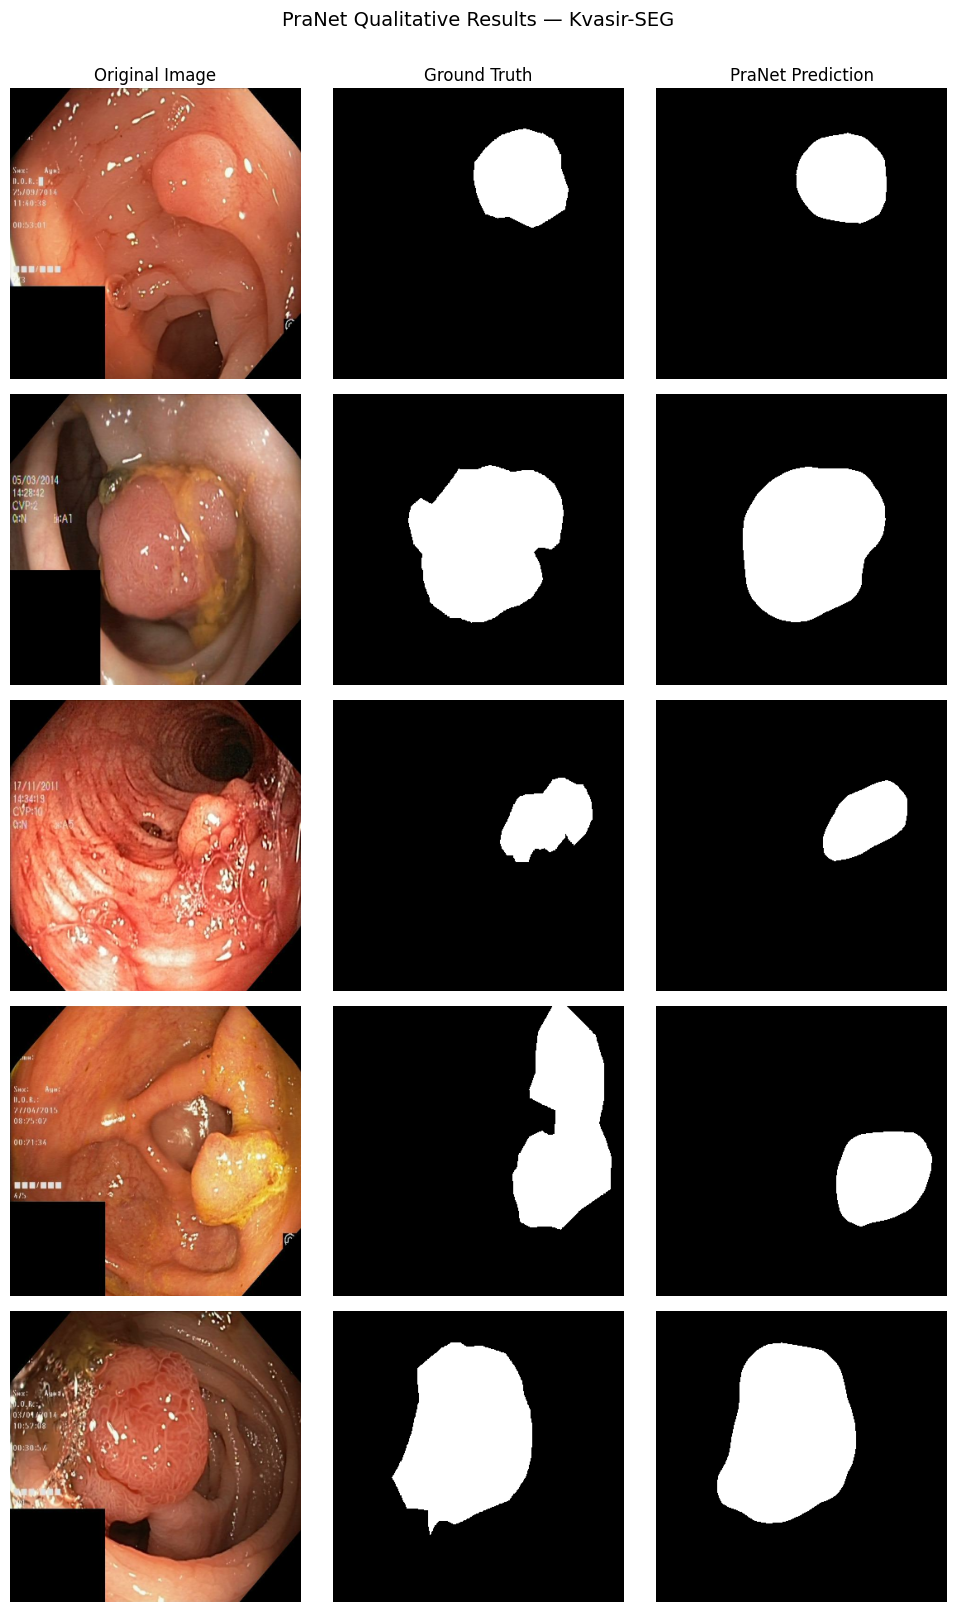

In [18]:
# =============================================================================
# CELL 10 — Qualitative visualization: Image | Ground Truth | Prediction
# =============================================================================
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt

def visualize_predictions(model, pairs, img_size: int, n_samples: int = 5,
                           threshold: float = 0.5, dataset_name: str = "Dataset",
                           seed: int = 42):
    if not pairs:
        print(f"[skip] No samples available to visualize for {dataset_name}.")
        return

    rng = random.Random(seed)
    sample_pairs = rng.sample(pairs, k=min(n_samples, len(pairs)))

    fig, axes = plt.subplots(len(sample_pairs), 3, figsize=(10, 3.2 * len(sample_pairs)))
    if len(sample_pairs) == 1:
        axes = np.expand_dims(axes, axis=0)

    fig.suptitle(f"PraNet Qualitative Results — {dataset_name}", fontsize=14, y=1.005)

    for row, (img_path, mask_path) in enumerate(sample_pairs):
        img, mask = _load_image_mask(img_path, mask_path, img_size)
        img_batch = tf.expand_dims(img, axis=0)

        probs = pranet_predict(model, img_batch)
        pred_bin = tf.cast(probs > threshold, tf.float32)[0, ..., 0].numpy()

        axes[row, 0].imshow(img.numpy())
        axes[row, 0].set_title("Original Image" if row == 0 else "")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask.numpy()[..., 0], cmap="gray")
        axes[row, 1].set_title("Ground Truth" if row == 0 else "")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_bin, cmap="gray")
        axes[row, 2].set_title("PraNet Prediction" if row == 0 else "")
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()


if kvasir_pairs:
    visualize_predictions(
        pranet_model, 
        kvasir_pairs, 
        img_size=INPUT_SIZE, 
        n_samples=5, 
        threshold=THRESHOLD, 
        dataset_name="Kvasir-SEG"
    )
else:
    print("[skip] Kvasir-SEG visualization skipped (no evaluated samples).")